### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms

from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

### Train Val Split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=876567
)

train_idx, val_idx = next(sgkf.split(df, df['dx'], df['lesion_id']))
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'val'

output_filename = "HAM10000_metadata_split_80_20.csv"
df.to_csv(output_filename, index=False)

split = pd.read_csv("/kaggle/working/HAM10000_metadata_split_80_20.csv")

train_df = split[split['split'] == 'train']
val_df = split[split['split'] == 'val']

print(train_df.shape)
print(val_df.shape)

(8033, 8)
(1982, 8)


### Caching

In [3]:
IMG_SIZE = 380
img_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

label_map = {label : idx for idx, label in enumerate(sorted(split['dx'].unique()))}

path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.endswith(".jpg"):
            image_id = fname[:-4]
            path_map[image_id] = os.path.join(d, fname)

resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

def build_cache(df, path_map, save_path):
    images = torch.zeros((len(df), 3, 380, 380), dtype=torch.float32)
    for i, row in df.reset_index(drop=True).iterrows():
        img = Image.open(path_map[row['image_id']]).convert('RGB')
        images[i] = resize_only(img)
        if i % 1000 == 0:
            print(f"{i}/{len(df)}")
    torch.save(images, save_path)
    print(f"Saved cache to {save_path}")

# build once, reuse across all 20 epochs
build_cache(train_df, path_map, '/kaggle/working/train_cache.pt')
build_cache(val_df, path_map, '/kaggle/working/val_cache.pt')

0/8033
1000/8033
2000/8033
3000/8033
4000/8033
5000/8033
6000/8033
7000/8033
8000/8033
Saved cache to /kaggle/working/train_cache.pt
0/1982
1000/1982
Saved cache to /kaggle/working/val_cache.pt


In [4]:
class_names = sorted(label_map, key=label_map.get)

print(class_names)
print(label_map)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### Dataset/DataLoader

In [5]:
class CachedHAMDataset(Dataset):
    def __init__(self, cache_path, df, label_map, augment=None):
        self.images = torch.load(cache_path)
        self.labels = [label_map[l] for l in df['dx']]

        # augmentation
        self.train_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
        ])

        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.augment:
            img = self.train_aug(img)

        return img, self.labels[idx]


# ---

train_cache_path = "/kaggle/working/train_cache.pt"
val_cache_path = "/kaggle/working/val_cache.pt"

train_ds = CachedHAMDataset(train_cache_path, train_df, label_map, augment=True)
val_ds = CachedHAMDataset(val_cache_path, val_df, label_map, augment=False)

class_counts = train_df['dx'].value_counts().reindex(class_names)
class_weights = 1.0 / class_counts
sample_weights = train_df['dx'].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Training

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

model = timm.create_model("efficientnet_b4", pretrained=True, num_classes=7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        images = (images - MEAN) / STD

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device)
            images = (images - MEAN) / STD

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / total, correct / total, macro_f1

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [7]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []
}

best_f1 = 0.0
NUM_EPOCHS = 20
CHECKPOINT_PATH = 'best_model_oversample_aug.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
        }, CHECKPOINT_PATH)
        print(f"  → New best model saved (F1: {val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_f1:.4f}")

  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.1548 Acc: 0.5681 | Val Loss: 0.8587 Acc: 0.7003 F1: 0.5225
  → New best model saved (F1: 0.5225)


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 0.5450 Acc: 0.8048 | Val Loss: 0.6753 Acc: 0.7523 F1: 0.6212
  → New best model saved (F1: 0.6212)


  0%|          | 0/251 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 0.0296 Acc: 0.9909 | Val Loss: 0.7054 Acc: 0.8476 F1: 0.6994


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.0326 Acc: 0.9882 | Val Loss: 0.7466 Acc: 0.8264 F1: 0.6941


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.0306 Acc: 0.9879 | Val Loss: 0.7006 Acc: 0.8496 F1: 0.7120

Training complete. Best Val F1: 0.7203


### Plots

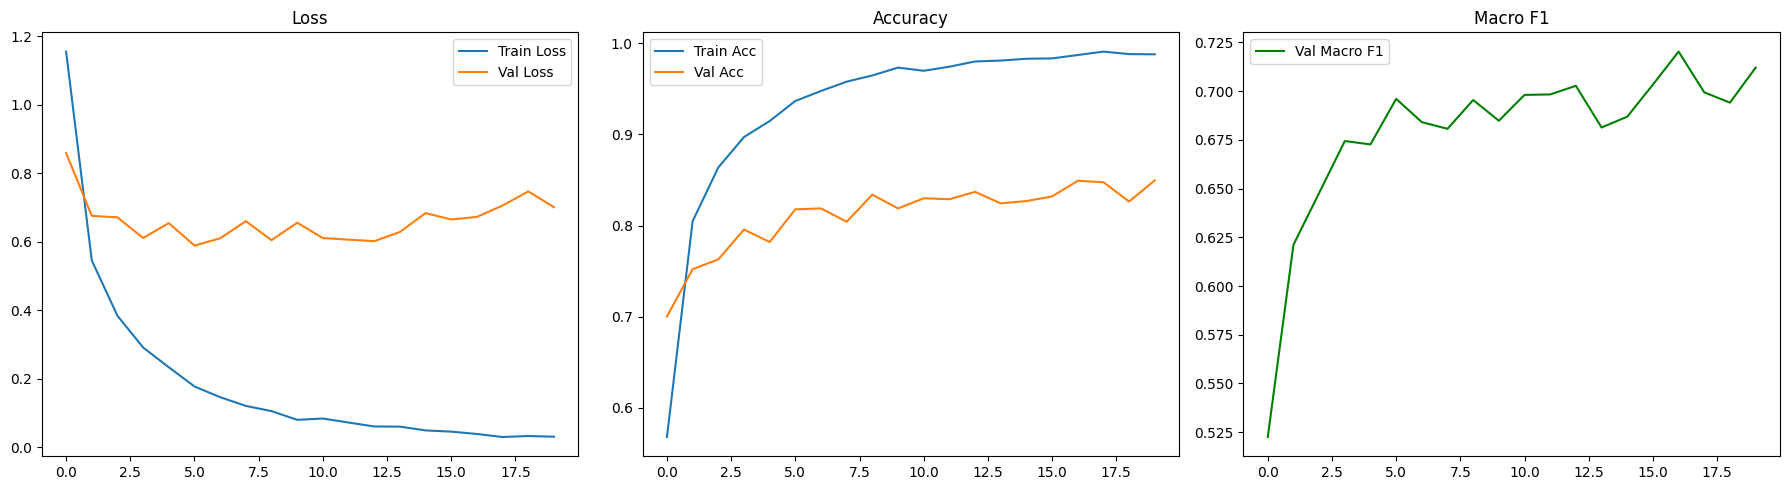

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.tight_layout()
plt.show()

Loaded best model from epoch 17, F1: 0.7203


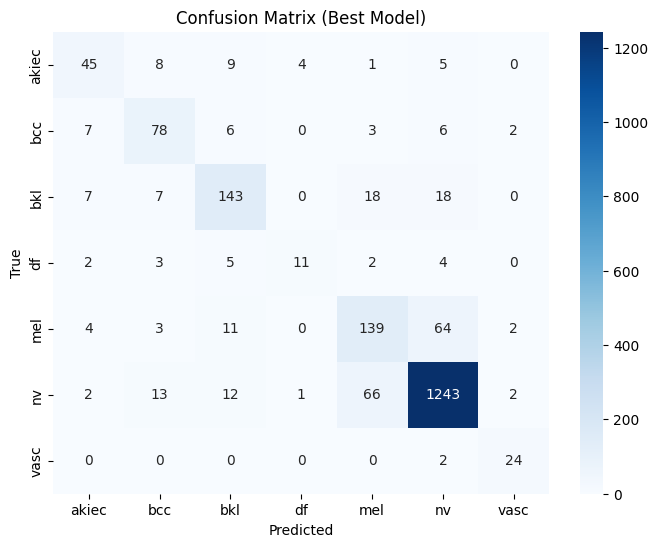

              precision    recall  f1-score   support

       akiec      0.672     0.625     0.647        72
         bcc      0.696     0.765     0.729       102
         bkl      0.769     0.741     0.755       193
          df      0.688     0.407     0.512        27
         mel      0.607     0.623     0.615       223
          nv      0.926     0.928     0.927      1339
        vasc      0.800     0.923     0.857        26

    accuracy                          0.849      1982
   macro avg      0.737     0.716     0.720      1982
weighted avg      0.849     0.849     0.848      1982



In [9]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}, F1: {checkpoint['val_f1']:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        images = (images - MEAN) / STD
        with torch.cuda.amp.autocast():
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = sorted(label_map, key=label_map.get)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Best Model)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))